# LLM Inference Perf Lab (Colab)

Runs vLLM in this Colab runtime, then exercises it with the OpenAI-compatible client from `src/client.py`.

**Requirements**
- Colab runtime with a GPU (Runtime → Change runtime type → GPU)
- Run cells top to bottom (or Runtime → Run all)

**Sections**
1. Environment setup
2. Start vLLM server
3. Client configuration
4. Single request benchmark
5. Streaming benchmark
6. Concurrency sweep

Setup cells are adapted from `notebooks/vllm_setup.ipynb`. The first `vllm serve` run downloads `Qwen/Qwen2.5-1.5B-Instruct` from Hugging Face.


## 1. Environment setup

GPU check, install PyTorch / vLLM / OpenAI client, then verify imports.

### GPU

In [1]:
!nvidia-smi

Sat Jul 18 01:12:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install

In [2]:
!pip install -q uv
!pip install -q \
  "torch==2.9.0" \
  "torchvision==0.24.0" \
  "torchaudio==2.9.0" \
  --index-url https://download.pytorch.org/whl/cu128

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 82.6 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 57.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 62.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 112.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 900.9/900.9 MB 879.5 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 108.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 6.6 MB/s eta 0:00:00:00:0100:01


In [3]:
!pip install -q "vllm==0.11.2" openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.3/370.3 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.0/355.0 kB 604.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 546.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 8.0 MB/s eta 0:00:00:00:0100:

### Verify

In [4]:
import importlib.metadata as metadata
import torch

print("Installed vLLM package:", metadata.version("vllm"))
print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Installed vLLM package: 0.11.2
PyTorch: 2.9.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
GPU: Tesla T4


In [5]:
import vllm

print("vLLM import successful")
print("vLLM version:", vllm.__version__)

vLLM import successful
vLLM version: 0.11.2


## 2. Start vLLM server

Serves `Qwen/Qwen2.5-1.5B-Instruct` as `qwen2.5-1.5b` on port 8000. Logs go to `/content/vllm_server.log`.

First start can take several minutes while the model downloads and loads. The wait cell tails the log so you can watch progress.

### Launch

In [6]:
%%bash

nohup vllm serve Qwen/Qwen2.5-1.5B-Instruct \
  --host 0.0.0.0 \
  --port 8000 \
  --served-model-name qwen2.5-1.5b \
  --dtype half \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.85 \
  > /content/vllm_server.log 2>&1 &

echo $! > /content/vllm_server.pid
echo "Server process started with PID $(cat /content/vllm_server.pid)"

Server process started with PID 1696


### Wait until ready

In [7]:
import os
import time
from pathlib import Path

import requests

url = "http://127.0.0.1:8000/v1/models"
log_path = Path("/content/vllm_server.log")
pid_path = Path("/content/vllm_server.pid")

pid = int(pid_path.read_text().strip())
log_offset = 0
started = time.monotonic()
poll_s = 2

print(f"Waiting for server (PID {pid}) to become ready...")
print(f"Tailing {log_path}\n")

while True:
    if log_path.exists():
        with log_path.open("r", errors="replace") as log_file:
            log_file.seek(log_offset)
            chunk = log_file.read()
            log_offset = log_file.tell()
        if chunk:
            print(chunk, end="" if chunk.endswith("\n") else "\n", flush=True)

    try:
        response = requests.get(url, timeout=2)
        if response.status_code == 200:
            elapsed_s = time.monotonic() - started
            print(f"\nServer is ready after {elapsed_s:.0f}s.")
            print(response.json())
            break
    except requests.RequestException:
        pass

    try:
        os.kill(pid, 0)
    except OSError as exc:
        print("\nServer process exited before becoming ready.")
        print("\nLast part of server log:\n")
        if log_path.exists():
            print(log_path.read_text(errors="replace")[-5000:])
        raise RuntimeError(f"vLLM server process {pid} is not running") from exc

    time.sleep(poll_s)


Waiting for server (PID 1696) to become ready...
Tailing /content/vllm_server.log

2026-07-18 01:16:29.606445: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO 07-18 01:16:42 [scheduler.py:216] Chunked prefill is enabled with max_num_batched_tokens=2048.
(APIServer pid=1696) INFO 07-18 01:16:42 [api_server.py:1977] vLLM API server version 0.11.2
(APIServer pid=1696) INFO 07-18 01:16:42 [utils.py:253] non-default args: {'model_tag': 'Qwen/Qwen2.5-1.5B-Instruct', 'host': '0.0.0.0', 'model': 'Qwen/Qwen2.5-1.5B-Instruct', 'dtype': 'half', 'max_model_len': 2048, 'served_model_name': ['qwen2.5-1.5b'], 'gpu_memory_utilization': 0.85}
(APIServer pid=1696) INFO 07-18 01:17:04 [model.py:631] Resolved architecture: Qwen2ForCausalLM
(APIServer pid=1696) 

## 3. Client configuration

Defaults match `src/client.py` and the local vLLM server started above.

### Settings

In [8]:
# @title Client settings
BASE_URL = "http://127.0.0.1:8000/v1"  # @param {type:"string"}
API_KEY = "not-needed"  # @param {type:"string"}
MODEL_NAME = "qwen2.5-1.5b"  # @param {type:"string"}
MAX_TOKENS = 100  # @param {type:"integer"}
TEMPERATURE = 0.0  # @param {type:"number"}
PROMPT = "What is LLM inference latency?"  # @param {type:"string"}

print(f"base_url={BASE_URL}")
print(f"model={MODEL_NAME}")

base_url=http://127.0.0.1:8000/v1
model=qwen2.5-1.5b


### Create client

In [9]:
from openai import OpenAI

client = OpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
)

print("Client ready.")

Client ready.


## 4. Single request benchmark

Same call as `src/client.py`, with wall-clock latency.

In [10]:
import time

t0 = time.perf_counter()
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": PROMPT,
        },
    ],
    max_tokens=MAX_TOKENS,
    temperature=TEMPERATURE,
)
elapsed_s = time.perf_counter() - t0

content = response.choices[0].message.content
usage = response.usage

print(content)
print()
print(f"latency_s={elapsed_s:.3f}")
if usage is not None:
    print(f"prompt_tokens={usage.prompt_tokens}")
    print(f"completion_tokens={usage.completion_tokens}")
    print(f"total_tokens={usage.total_tokens}")
    if usage.completion_tokens and elapsed_s > 0:
        # E2E rate (includes prefill/scheduling/HTTP), not pure decode throughput.
        print(
            f"output_tokens_per_e2e_s={usage.completion_tokens / elapsed_s:.2f}"
        )

LLM inference latency refers to the time it takes for an artificial intelligence language model (LLM) to generate a response or output after receiving input data. This can be influenced by various factors such as:

1. Model complexity: More complex models may take longer to process and respond.

2. Data size: Larger datasets require more processing power and time to analyze.

3. Hardware limitations: The computational resources available on the server hosting the model will affect performance.

4. Network conditions: Slow internet connections

latency_s=4.031
prompt_tokens=36
completion_tokens=100
total_tokens=136
output_tokens_per_e2e_s=24.81


## 5. Streaming benchmark

Measures time-to-first-token (TTFT) and end-to-end latency.

In [11]:
import time

t0 = time.perf_counter()
ttft_s = None
chunks: list[str] = []
usage = None

stream = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": PROMPT}],
    max_tokens=MAX_TOKENS,
    temperature=TEMPERATURE,
    stream=True,
    stream_options={"include_usage": True},
)

for event in stream:
    if getattr(event, "usage", None) is not None:
        usage = event.usage
    if not event.choices:
        continue
    delta = event.choices[0].delta.content
    if not delta:
        continue
    if ttft_s is None:
        ttft_s = time.perf_counter() - t0
    chunks.append(delta)
    print(delta, end="", flush=True)

elapsed_s = time.perf_counter() - t0
print()
print()
print(f"ttft_s={ttft_s:.3f}" if ttft_s is not None else "ttft_s=n/a")
print(f"e2e_latency_s={elapsed_s:.3f}")
print(f"output_chars={sum(len(c) for c in chunks)}")
if usage is not None:
    print(f"prompt_tokens={usage.prompt_tokens}")
    print(f"completion_tokens={usage.completion_tokens}")
    print(f"total_tokens={usage.total_tokens}")
    if usage.completion_tokens and elapsed_s > 0:
        print(
            f"output_tokens_per_e2e_s={usage.completion_tokens / elapsed_s:.2f}"
        )
else:
    print("usage=n/a (stream did not include usage)")


LLM inference latency refers to the time it takes for an artificial intelligence language model (LLM) to generate a response or output after receiving input data. This can be influenced by various factors such as:

1. Model complexity: More complex models may take longer to process and respond.

2. Data size: Larger datasets require more processing power and time to analyze.

3. Hardware limitations: The computational resources available on the server hosting the model will affect performance.

4. Network conditions: Slow internet connections

ttft_s=0.073
e2e_latency_s=1.680
output_chars=548
prompt_tokens=36
completion_tokens=100
total_tokens=136
output_tokens_per_e2e_s=59.53


## 6. Concurrency sweep

Fires the same prompt at several concurrency levels (thread pool). For each level, records per-request latency/`usage` and batch wall-clock throughput.

Writes `results/concurrency_raw.csv` and `results/concurrency_summary.csv`.

In [14]:
def run_one_request(request_id, prompt_name, prompt):
    t0 = time.perf_counter()

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )

    elapsed_s = time.perf_counter() - t0

    usage = response.usage

    prompt_tokens = usage.prompt_tokens if usage is not None else None
    completion_tokens = usage.completion_tokens if usage is not None else None
    total_tokens = usage.total_tokens if usage is not None else None

    output_tokens_per_e2e_s = None
    if completion_tokens is not None and elapsed_s > 0:
        output_tokens_per_e2e_s = completion_tokens / elapsed_s

    return {
        "request_id": request_id,
        "prompt_name": prompt_name,
        "prompt_characters": len(prompt),
        "latency_s": elapsed_s,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": total_tokens,
        "output_tokens_per_e2e_s": output_tokens_per_e2e_s,
    }

In [15]:
result = run_one_request(
    request_id=0,
    prompt_name="default",
    prompt=PROMPT,
)
print(result)

{'request_id': 0, 'prompt_name': 'default', 'prompt_characters': 30, 'latency_s': 1.6724199380000755, 'prompt_tokens': 36, 'completion_tokens': 100, 'total_tokens': 136, 'output_tokens_per_e2e_s': 59.793594735292785}


In [16]:
from concurrent.futures import ThreadPoolExecutor, as_completed


def run_concurrency_level(
    concurrency,
    repeat_id,
    prompt_name,
    prompt,
):
    experiment_start = time.perf_counter()

    results = []

    with ThreadPoolExecutor(max_workers=concurrency) as executor:
        futures = [
            executor.submit(
                run_one_request,
                request_id,
                prompt_name,
                prompt,
            )
            for request_id in range(concurrency)
        ]

        for future in as_completed(futures):
            results.append(future.result())

    experiment_elapsed_s = time.perf_counter() - experiment_start

    total_output_tokens = sum(
        result["completion_tokens"] or 0
        for result in results
    )

    aggregate_output_tokens_per_s = None
    if experiment_elapsed_s > 0:
        aggregate_output_tokens_per_s = (
            total_output_tokens / experiment_elapsed_s
        )

    for result in results:
        result["repeat_id"] = repeat_id
        result["concurrency"] = concurrency
        result["experiment_elapsed_s"] = experiment_elapsed_s
        result["aggregate_output_tokens_per_s"] = (
            aggregate_output_tokens_per_s
        )

    return results

In [18]:
results = run_concurrency_level(
    concurrency=2,
    repeat_id=0,
    prompt_name="default",
    prompt=PROMPT,
)

experiment_elapsed_s = results[0]["experiment_elapsed_s"]
print(f"Experiment elapsed time: {experiment_elapsed_s:.3f}s")
for result in sorted(results, key=lambda r: r["latency_s"]):
    print(result)


Experiment elapsed time: 1.704s
{'request_id': 0, 'prompt_name': 'default', 'prompt_characters': 30, 'latency_s': 1.6883888040001693, 'prompt_tokens': 36, 'completion_tokens': 100, 'total_tokens': 136, 'output_tokens_per_e2e_s': 59.22806391695901, 'repeat_id': 0, 'concurrency': 2, 'experiment_elapsed_s': 1.7044456419998824, 'aggregate_output_tokens_per_s': 117.34020438770543}
{'request_id': 1, 'prompt_name': 'default', 'prompt_characters': 30, 'latency_s': 1.7009303259997068, 'prompt_tokens': 36, 'completion_tokens': 100, 'total_tokens': 136, 'output_tokens_per_e2e_s': 58.791355807725914, 'repeat_id': 0, 'concurrency': 2, 'experiment_elapsed_s': 1.7044456419998824, 'aggregate_output_tokens_per_s': 117.34020438770543}


In [19]:
import os
import pandas as pd

concurrency_levels = [1, 2, 4, 8]
num_repeats = 3

all_results = []

for concurrency in concurrency_levels:
    for repeat_id in range(num_repeats):
        print(
            f"Running concurrency={concurrency}, "
            f"repeat={repeat_id}..."
        )

        results = run_concurrency_level(
            concurrency=concurrency,
            repeat_id=repeat_id,
            prompt_name="default",
            prompt=PROMPT,
        )

        all_results.extend(results)

        experiment_elapsed_s = results[0]["experiment_elapsed_s"]
        aggregate_throughput = results[0][
            "aggregate_output_tokens_per_s"
        ]

        print(
            f"  elapsed={experiment_elapsed_s:.3f}s, "
            f"aggregate_output_tokens_per_s="
            f"{aggregate_throughput:.2f}"
        )

        # Brief pause so consecutive experiments are clearly separated.
        time.sleep(1)

Running concurrency=1, repeat=0...
  elapsed=1.670s, aggregate_output_tokens_per_s=59.87
Running concurrency=1, repeat=1...
  elapsed=1.644s, aggregate_output_tokens_per_s=60.84
Running concurrency=1, repeat=2...
  elapsed=1.611s, aggregate_output_tokens_per_s=62.09
Running concurrency=2, repeat=0...
  elapsed=1.646s, aggregate_output_tokens_per_s=121.48
Running concurrency=2, repeat=1...
  elapsed=1.658s, aggregate_output_tokens_per_s=120.64
Running concurrency=2, repeat=2...
  elapsed=1.685s, aggregate_output_tokens_per_s=118.66
Running concurrency=4, repeat=0...
  elapsed=1.684s, aggregate_output_tokens_per_s=237.51
Running concurrency=4, repeat=1...
  elapsed=1.683s, aggregate_output_tokens_per_s=237.68
Running concurrency=4, repeat=2...
  elapsed=1.691s, aggregate_output_tokens_per_s=236.54
Running concurrency=8, repeat=0...
  elapsed=1.778s, aggregate_output_tokens_per_s=450.02
Running concurrency=8, repeat=1...
  elapsed=1.805s, aggregate_output_tokens_per_s=443.34
Running concu

In [20]:
df = pd.DataFrame(all_results)

column_order = [
    "repeat_id",
    "concurrency",
    "request_id",
    "latency_s",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
    "output_tokens_per_e2e_s",
    "experiment_elapsed_s",
    "aggregate_output_tokens_per_s",
]

df = (
    df[column_order]
    .sort_values(["concurrency", "repeat_id", "request_id"])
    .reset_index(drop=True)
)

display(df)

,repeat_id,concurrency,request_id,latency_s,prompt_tokens,completion_tokens,total_tokens,output_tokens_per_e2e_s,experiment_elapsed_s,aggregate_output_tokens_per_s
0,0,1,0,1.669916,36,100,136,59.883234,1.670389,59.866304
1,1,1,0,1.642845,36,100,136,60.870026,1.643567,60.843288
2,2,1,0,1.610122,36,100,136,62.107110,1.610597,62.088765
3,0,2,0,1.629969,36,100,136,61.350844,1.646304,121.484239
4,0,2,1,1.644017,36,100,136,60.826615,1.646304,121.484239
5,1,2,0,1.641295,36,100,136,60.927488,1.657801,120.641743
6,1,2,1,1.655425,36,100,136,60.407439,1.657801,120.641743
7,2,2,0,1.684934,36,100,136,59.349514,1.685450,118.662650
8,2,2,1,1.664874,36,100,136,60.064613,1.685450,118.662650
9,0,4,0,1.664943,36,100,136,60.062110,1.684107,237.514666


In [21]:
os.makedirs("results", exist_ok=True)

output_path = "results/concurrency_raw.csv"
df.to_csv(output_path, index=False)

print(f"Saved {len(df)} rows to {output_path}")

Saved 45 rows to results/concurrency_raw.csv


In [22]:
# Backup CSV before the Colab runtime disconnects.
try:
    from google.colab import files

    files.download("results/concurrency_raw.csv")
except ImportError:
    print("Not running in Colab; skip files.download(). CSV is at results/concurrency_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Concurrency Analysis


In [23]:
experiment_df = (
    df[
        [
            "concurrency",
            "repeat_id",
            "experiment_elapsed_s",
            "aggregate_output_tokens_per_s",
        ]
    ]
    .drop_duplicates(
        subset=["concurrency", "repeat_id"]
    )
    .sort_values(["concurrency", "repeat_id"])
    .reset_index(drop=True)
)

display(experiment_df)


,concurrency,repeat_id,experiment_elapsed_s,aggregate_output_tokens_per_s
0,1,0,1.670389,59.866304
1,1,1,1.643567,60.843288
2,1,2,1.610597,62.088765
3,2,0,1.646304,121.484239
4,2,1,1.657801,120.641743
5,2,2,1.685450,118.662650
6,4,0,1.684107,237.514666
7,4,1,1.682926,237.681286
8,4,2,1.691050,236.539392
9,8,0,1.777705,450.018307


In [24]:
run_summary = (
    df.groupby(["concurrency", "repeat_id"], as_index=False)
    .agg(
        mean_request_latency_s=("latency_s", "mean"),
        min_request_latency_s=("latency_s", "min"),
        max_request_latency_s=("latency_s", "max"),
        experiment_elapsed_s=("experiment_elapsed_s", "first"),
        aggregate_output_tokens_per_s=(
            "aggregate_output_tokens_per_s",
            "first",
        ),
    )
)

display(run_summary)

,concurrency,repeat_id,mean_request_latency_s,min_request_latency_s,max_request_latency_s,experiment_elapsed_s,aggregate_output_tokens_per_s
0,1,0,1.669916,1.669916,1.669916,1.670389,59.866304
1,1,1,1.642845,1.642845,1.642845,1.643567,60.843288
2,1,2,1.610122,1.610122,1.610122,1.610597,62.088765
3,2,0,1.636993,1.629969,1.644017,1.646304,121.484239
4,2,1,1.648360,1.641295,1.655425,1.657801,120.641743
5,2,2,1.674904,1.664874,1.684934,1.685450,118.662650
6,4,0,1.675357,1.664943,1.679820,1.684107,237.514666
7,4,1,1.674276,1.663680,1.678797,1.682926,237.681286
8,4,2,1.682612,1.672018,1.687006,1.691050,236.539392
9,8,0,1.765045,1.748847,1.774332,1.777705,450.018307


In [25]:
summary_df = (
    run_summary.groupby("concurrency", as_index=False)
    .agg(
        mean_latency_s=("mean_request_latency_s", "mean"),
        std_latency_s=("mean_request_latency_s", "std"),
        mean_experiment_elapsed_s=("experiment_elapsed_s", "mean"),
        mean_aggregate_output_tokens_per_s=(
            "aggregate_output_tokens_per_s",
            "mean",
        ),
        std_aggregate_output_tokens_per_s=(
            "aggregate_output_tokens_per_s",
            "std",
        ),
    )
)

baseline_throughput = summary_df.loc[
    summary_df["concurrency"] == 1,
    "mean_aggregate_output_tokens_per_s",
].iloc[0]

summary_df["throughput_scaling"] = (
    summary_df["mean_aggregate_output_tokens_per_s"]
    / baseline_throughput
)

summary_df["scaling_efficiency"] = (
    summary_df["throughput_scaling"]
    / summary_df["concurrency"]
)

display(summary_df)

,concurrency,mean_latency_s,std_latency_s,mean_experiment_elapsed_s,mean_aggregate_output_tokens_per_s,std_aggregate_output_tokens_per_s,throughput_scaling,scaling_efficiency
0,1,1.640961,0.029942,1.641518,60.932786,1.113930,1.000000,1.000000
1,2,1.653419,0.019455,1.663185,120.262877,1.448446,1.973697,0.986849
2,4,1.677415,0.004533,1.686028,237.245115,0.616826,3.893554,0.973389
3,8,1.767306,0.022660,1.780089,449.467077,5.875564,7.376441,0.922055


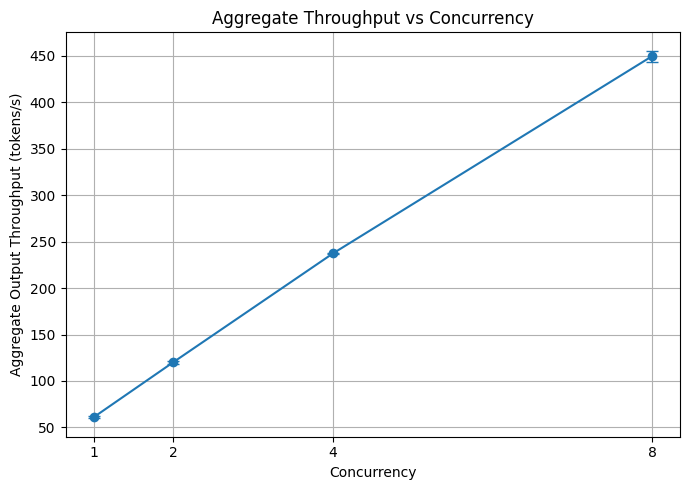

In [26]:
import os
import matplotlib.pyplot as plt

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["concurrency"],
    summary_df["mean_aggregate_output_tokens_per_s"],
    yerr=summary_df["std_aggregate_output_tokens_per_s"],
    marker="o",
    capsize=4,
)

plt.xlabel("Concurrency")
plt.ylabel("Aggregate Output Throughput (tokens/s)")
plt.title("Aggregate Throughput vs Concurrency")
plt.xticks(summary_df["concurrency"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "plots/throughput_vs_concurrency.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

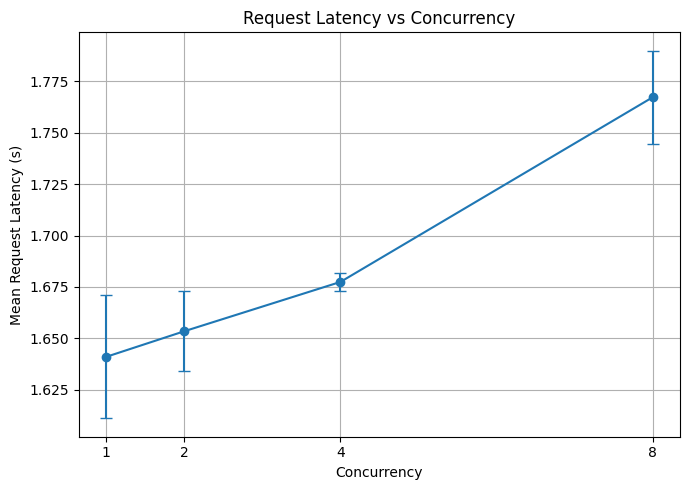

In [27]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["concurrency"],
    summary_df["mean_latency_s"],
    yerr=summary_df["std_latency_s"],
    marker="o",
    capsize=4,
)

plt.xlabel("Concurrency")
plt.ylabel("Mean Request Latency (s)")
plt.title("Request Latency vs Concurrency")
plt.xticks(summary_df["concurrency"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "plots/latency_vs_concurrency.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [28]:
summary_df.to_csv(
    "results/concurrency_summary.csv",
    index=False,
)

print("Saved:")
print("- results/concurrency_raw.csv")
print("- results/concurrency_summary.csv")
print("- plots/latency_vs_concurrency.png")
print("- plots/throughput_vs_concurrency.png")

Saved:
- results/concurrency_raw.csv
- results/concurrency_summary.csv
- plots/latency_vs_concurrency.png
- plots/throughput_vs_concurrency.png


In [29]:
import shutil
from google.colab import files

shutil.make_archive(
    "concurrency_experiment",
    "zip",
    root_dir=".",
    base_dir="results",
)

files.download("concurrency_experiment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import os
import shutil
from google.colab import files

os.makedirs("concurrency_experiment/results", exist_ok=True)
os.makedirs("concurrency_experiment/plots", exist_ok=True)

shutil.copy(
    "results/concurrency_raw.csv",
    "concurrency_experiment/results/concurrency_raw.csv",
)
shutil.copy(
    "results/concurrency_summary.csv",
    "concurrency_experiment/results/concurrency_summary.csv",
)
shutil.copy(
    "plots/latency_vs_concurrency.png",
    "concurrency_experiment/plots/latency_vs_concurrency.png",
)
shutil.copy(
    "plots/throughput_vs_concurrency.png",
    "concurrency_experiment/plots/throughput_vs_concurrency.png",
)

shutil.make_archive(
    "concurrency_experiment",
    "zip",
    root_dir=".",
    base_dir="concurrency_experiment",
)

files.download("concurrency_experiment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Concurrency Sweep Observations

The concurrency sweep tested concurrency levels of 1, 2, 4, and 8, with
three repeated runs per level. Each request used the same 36-token prompt
and generated 100 output tokens.

Mean request latency increased from 1.649 seconds at concurrency 1 to
1.767 seconds at concurrency 8, an increase of approximately 7.1%.

Aggregate output throughput increased from 60.63 tokens/s to
449.82 tokens/s, representing a 7.42x throughput improvement at 8x
concurrency.

Scaling efficiency remained high, decreasing from 100% at concurrency 1
to approximately 92.7% at concurrency 8.

These results suggest that, for this workload, vLLM effectively batches
concurrent requests and increases total server throughput with only a
modest latency penalty.

This conclusion is limited to the tested environment and workload:
Tesla T4, Qwen2.5-1.5B-Instruct, a short 36-token prompt, 100 generated
tokens, and concurrency levels up to 8.

# Prompt Length Sweep

In [31]:
PROMPTS = {
    "short": (
        "Explain what LLM inference latency means."
    ),

    "medium": (
        "Explain the main performance stages of large language model "
        "inference. Discuss prefill, decoding, time to first token, "
        "end-to-end latency, output-token throughput, batching, and "
        "concurrency. Explain how these metrics interact and why improving "
        "throughput may increase individual request latency. Give a clear "
        "technical explanation suitable for an engineering student. "
    ) * 3,

    "long": (
        "Explain the architecture and performance characteristics of a "
        "large language model inference serving system. Discuss tokenization, "
        "request scheduling, continuous batching, the prefill phase, the "
        "decode phase, KV cache allocation, GPU compute utilization, memory "
        "bandwidth, arithmetic intensity, kernel launch overhead, latency, "
        "throughput, time to first token, time per output token, and tail "
        "latency. Explain how prompt length, output length, batch size, and "
        "concurrency affect system behavior. Also explain why prefill tends "
        "to have different computational characteristics from autoregressive "
        "decoding and why decoding can become memory-bandwidth-bound. "
    ) * 12,
}

In [32]:
for prompt_name, prompt in PROMPTS.items():
    print(
        prompt_name,
        "characters:",
        len(prompt),
        "words:",
        len(prompt.split()),
    )

short characters: 41 words: 6
medium characters: 1104 words: 144
long characters: 7872 words: 1008


In [33]:
test_results = []

for prompt_name, prompt in PROMPTS.items():
    level_results = run_concurrency_level(
        concurrency=1,
        repeat_id=0,
        prompt_name=prompt_name,
        prompt=prompt,
    )

    test_results.extend(level_results)

In [34]:
import pandas as pd

test_df = pd.DataFrame(test_results)

test_df[
    [
        "prompt_name",
        "prompt_characters",
        "prompt_tokens",
        "completion_tokens",
        "latency_s",
        "output_tokens_per_e2e_s",
    ]
]

,prompt_name,prompt_characters,prompt_tokens,completion_tokens,latency_s,output_tokens_per_e2e_s
0,short,41,38,100,1.666056,60.022008
1,medium,1104,217,100,1.636590,61.102646
2,long,7872,1387,100,1.791513,55.818731


In [35]:
PROMPT_SWEEP_REPEATS = 5
prompt_length_results = []

for prompt_name, prompt in PROMPTS.items():
    for repeat_id in range(PROMPT_SWEEP_REPEATS):
        print(
            f"Running prompt={prompt_name}, "
            f"repeat={repeat_id + 1}/{PROMPT_SWEEP_REPEATS}"
        )

        level_results = run_concurrency_level(
            concurrency=1,
            repeat_id=repeat_id,
            prompt_name=prompt_name,
            prompt=prompt,
        )

        prompt_length_results.extend(level_results)

Running prompt=short, repeat=1/5
Running prompt=short, repeat=2/5
Running prompt=short, repeat=3/5
Running prompt=short, repeat=4/5
Running prompt=short, repeat=5/5
Running prompt=medium, repeat=1/5
Running prompt=medium, repeat=2/5
Running prompt=medium, repeat=3/5
Running prompt=medium, repeat=4/5
Running prompt=medium, repeat=5/5
Running prompt=long, repeat=1/5
Running prompt=long, repeat=2/5
Running prompt=long, repeat=3/5
Running prompt=long, repeat=4/5
Running prompt=long, repeat=5/5


In [36]:
prompt_length_raw_df = pd.DataFrame(prompt_length_results)

prompt_length_raw_df[
    [
        "prompt_name",
        "repeat_id",
        "prompt_tokens",
        "completion_tokens",
        "latency_s",
        "output_tokens_per_e2e_s",
    ]
]

,prompt_name,repeat_id,prompt_tokens,completion_tokens,latency_s,output_tokens_per_e2e_s
0,short,0,38,100,1.671217,59.836643
1,short,1,38,100,1.606396,62.251160
2,short,2,38,100,1.606995,62.227931
3,short,3,38,100,1.609304,62.138652
4,short,4,38,100,1.609364,62.136348
5,medium,0,217,100,1.647455,60.699703
6,medium,1,217,100,1.661533,60.185368
7,medium,2,217,100,1.628487,61.406683
8,medium,3,217,100,1.625214,61.530376
9,medium,4,217,100,1.627439,61.446228


In [43]:
prompt_length_summary_df = (
    prompt_length_raw_df
    .groupby("prompt_name", as_index=False)
    .agg(
        prompt_tokens=("prompt_tokens", "mean"),
        mean_latency_s=("latency_s", "mean"),
        std_latency_s=("latency_s", "std"),
        min_latency_s=("latency_s", "min"),
        max_latency_s=("latency_s", "max"),
        mean_output_tokens_per_s=(
            "output_tokens_per_e2e_s",
            "mean",
        ),
    )
)

In [44]:
prompt_order = ["short", "medium", "long"]

prompt_length_summary_df["prompt_name"] = pd.Categorical(
    prompt_length_summary_df["prompt_name"],
    categories=prompt_order,
    ordered=True,
)

prompt_length_summary_df = (
    prompt_length_summary_df
    .sort_values("prompt_name")
    .reset_index(drop=True)
)

prompt_length_summary_df

,prompt_name,prompt_tokens,mean_latency_s,std_latency_s,min_latency_s,max_latency_s,mean_output_tokens_per_s
0,short,38.0,1.620655,0.028296,1.606396,1.671217,61.718146
1,medium,217.0,1.638026,0.015880,1.625214,1.661533,61.053672
2,long,1387.0,1.652847,0.018962,1.638115,1.682556,60.507978


In [42]:
os.makedirs("results", exist_ok=True)

prompt_length_raw_path = "results/prompt_length_raw.csv"
prompt_length_summary_path = "results/prompt_length_summary.csv"

prompt_length_raw_df.to_csv(
    prompt_length_raw_path,
    index=False,
)

prompt_length_summary_df.to_csv(
    prompt_length_summary_path,
    index=False,
)

print("Saved:", prompt_length_raw_path)
print("Saved:", prompt_length_summary_path)

Saved: results/prompt_length_raw.csv
Saved: results/prompt_length_summary.csv


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
plot_df = prompt_length_summary_df.copy()

x = plot_df["prompt_tokens"].astype(float)
y = plot_df["mean_latency_s"].astype(float)
yerr = plot_df["std_latency_s"].astype(float)

plt.figure(figsize=(7, 4.5))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    marker="o",
    capsize=4,
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["prompt_name"],
        (
            float(row["prompt_tokens"]),
            float(row["mean_latency_s"]),
        ),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.xlabel("Prompt Tokens")
plt.ylabel("Mean End-to-End Latency (s)")
plt.title("End-to-End Latency vs Prompt Length")
plt.grid(True, alpha=0.3)
plt.tight_layout()

latency_plot_path = (
    PLOTS_DIR / "latency_vs_prompt_length.png"
)

plt.savefig(
    latency_plot_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", latency_plot_path)

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    x,
    plot_df["mean_output_tokens_per_s"],
    marker="o",
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["prompt_name"],
        (
            float(row["prompt_tokens"]),
            float(row["mean_output_tokens_per_s"]),
        ),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.xlabel("Prompt Tokens")
plt.ylabel("Mean Output Tokens per Second")
plt.title("Output Throughput vs Prompt Length")
plt.grid(True, alpha=0.3)
plt.tight_layout()

throughput_plot_path = (
    PLOTS_DIR / "throughput_vs_prompt_length.png"
)

plt.savefig(
    throughput_plot_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", throughput_plot_path)

### Prompt Length Sweep Observations

Prompt lengths of 38, 217, and 1387 tokens were tested with
concurrency fixed at 1 and output length fixed at 100 tokens.

Mean end-to-end latency increased from 1.621 seconds for the short
prompt to 1.653 seconds for the long prompt, an increase of
approximately 2.0%.

Mean end-to-end output throughput decreased from 61.72 to 60.51
output tokens per second, a decrease of approximately 2.0%.

Although prompt length increased by approximately 36.5x, the change
in end-to-end latency was modest. For this workload, the fixed
100-token autoregressive decoding phase likely dominated total
request time, reducing the visible impact of additional prefill work.

These results do not imply that prompt length has no performance
impact. Time to first token or experiments with shorter output
lengths would provide a more direct measurement of prefill cost.

## Notes

| Piece | Source |
|---|---|
| GPU check, PyTorch/vLLM install, serve, readiness wait | `notebooks/vllm_setup.ipynb` |
| OpenAI client + latency helpers | `src/client.py` |
| Model | `Qwen/Qwen2.5-1.5B-Instruct` served as `qwen2.5-1.5b` |
| Endpoint | `http://127.0.0.1:8000/v1` (same Colab runtime) |
| Concurrency CSVs | `results/concurrency_raw.csv`, `results/concurrency_summary.csv` |
| Prompt-length CSVs | `results/prompt_length_raw.csv`, `results/prompt_length_summary.csv` |
| Prompt-length plots | `plots/latency_vs_prompt_length.png`, `plots/throughput_vs_prompt_length.png` |
| Archived runs | `results/run_YYYY-MM-DD/` (`latency_raw.csv`, `summary.md`) |

Server log: `/content/vllm_server.log`  
Server PID: `/content/vllm_server.pid`
